In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [40]:
df_gpu = pd.read_csv("results/exhaustive_gpu.csv", index_col=0)
df_gpu.sample(5)

,lens_list,loss_fn,inspector_kwargs,dev,num_batches,lenses,wall_time_s,cpu_mem_used_MB,peak_cpu_mem_MB,peak_gpu_mem_MB,num_params_M,comment
2,[<monitorch.lens.loss_metrics.LossMetrics obje...,CrossEntropyLoss(),{'visualizer': 'matplotlib'},cuda,50,['LossMetrics'],29.989,3.00,1097.98,4947.69,85.95,LossMetrics(); visualizer=matplotlib
28,[<monitorch.lens.parameter_norm.ParameterNorm ...,CrossEntropyLoss(),{'visualizer': 'print'},cuda,50,['ParameterNorm'],30.826,0.00,1908.27,4947.10,85.95,ParameterNorm(inplace=True); visualizer='print'
1,[<monitorch.lens.loss_metrics.LossMetrics obje...,CrossEntropyLoss(),{'visualizer': 'print'},cuda,50,['LossMetrics'],29.658,0.12,1099.41,4948.29,85.95,LossMetrics(); visualizer=print
0,[],CrossEntropyLoss(),{},cuda,50,['None'],29.658,256.88,1077.47,4950.72,85.95,baseline
17,[<monitorch.lens.parameter_gradient_activation...,CrossEntropyLoss(),{'visualizer': 'matplotlib'},cuda,50,['ParameterGradientActivation'],128.491,46.00,1791.17,4947.10,85.95,ParameterGradientActivation(inplace=True); vis...


In [41]:
df_cpu = pd.read_csv("results/checkpoint_31.csv", index_col=0)
df_cpu.sample(5)

,lens_list,loss_fn,inspector_kwargs,dev,num_batches,lenses,wall_time_s,cpu_mem_used_MB,peak_cpu_mem_MB,peak_gpu_mem_MB,num_params_M,comment
9,[<monitorch.lens.output_activation.OutputActiv...,CrossEntropyLoss(),{'visualizer': 'tensorboard'},cpu,50,['OutputActivation'],1347.958,-6257.41,2154.38,0,85.95,OutputActivation(inplace=False); visualizer='t...
7,[<monitorch.lens.output_activation.OutputActiv...,CrossEntropyLoss(),{'visualizer': 'print'},cpu,50,['OutputActivation'],1339.304,293.86,8591.23,0,85.95,OutputActivation(inplace=False); visualizer='p...
0,[],CrossEntropyLoss(),{},cpu,50,['None'],1282.848,6836.93,7860.75,0,85.95,baseline
14,[<monitorch.lens.parameter_gradient_geometry.P...,CrossEntropyLoss(),{'visualizer': 'matplotlib'},cpu,50,['ParameterGradientGeometry'],1325.540,212.38,8722.73,0,85.95,ParameterGradientGeometry(inplace=False); visu...
12,[<monitorch.lens.parameter_gradient_geometry.P...,CrossEntropyLoss(),{'visualizer': 'tensorboard'},cpu,50,['ParameterGradientGeometry'],1389.913,-5895.57,2594.91,0,85.95,ParameterGradientGeometry(inplace=True); visua...


In [45]:
baseline = df_gpu[df_gpu['comment'] == 'baseline'].iloc[0]

np.float64(29.658)

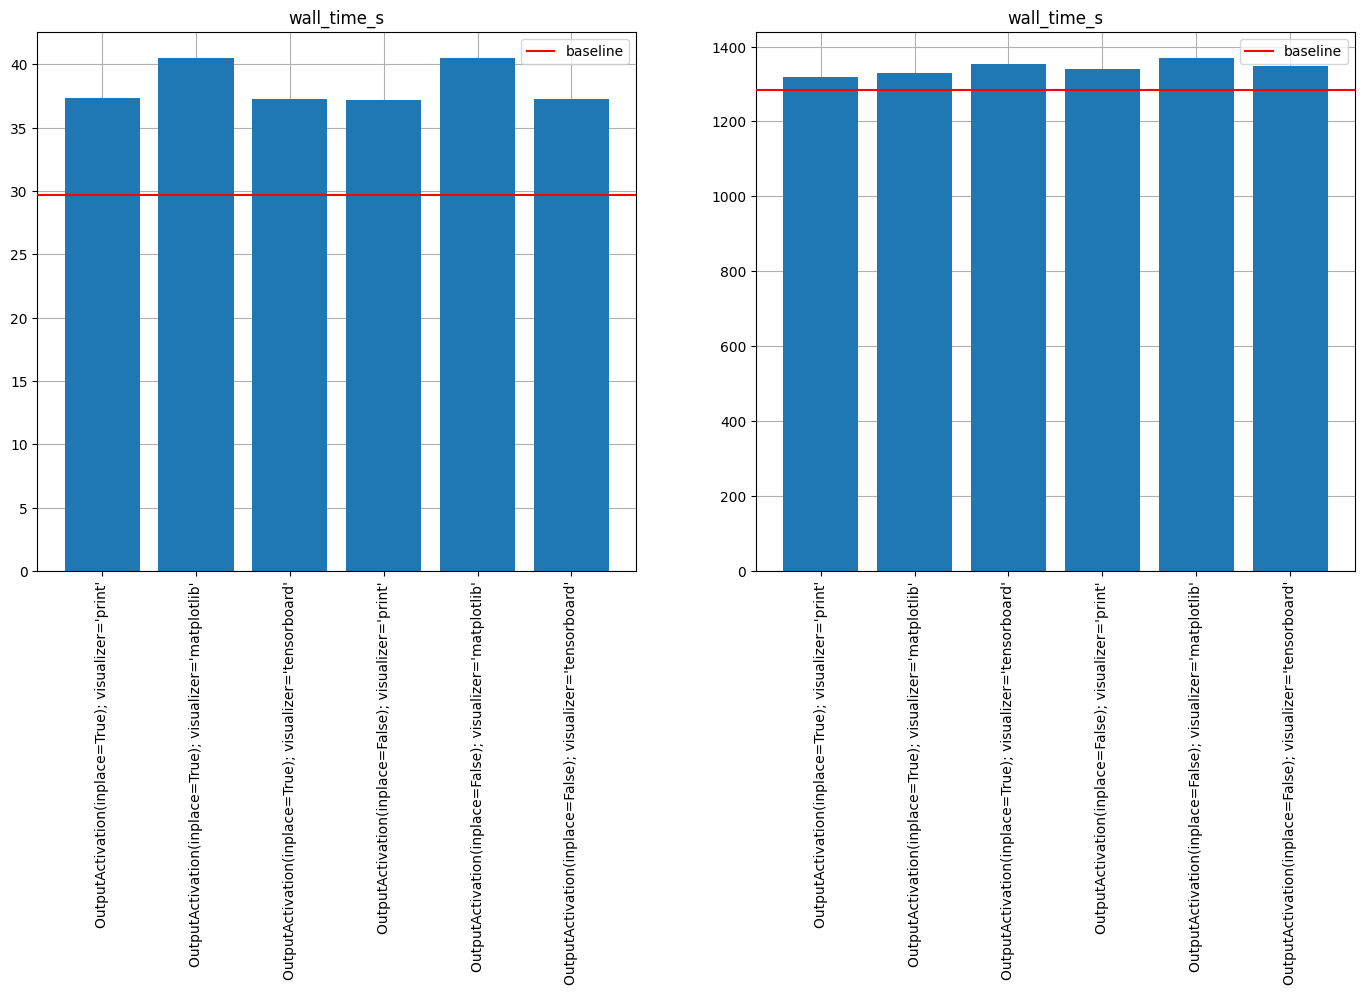

In [68]:
def display_lens_bm(lens_name, stat_name, df, ax):
    baseline = df[df['comment'] == 'baseline'].iloc[0]
    ser = df[df['comment'].str.contains(lens_name)]
    ax.bar(
        ser['comment'],
        ser[stat_name],
        zorder=2
    )
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(
        ser['comment'],
        rotation=90
    )
    ax.axhline(baseline[stat_name], c='r', zorder=3, label='baseline')
    ax.grid(zorder=0)
    ax.legend()
    ax.set_title(stat_name)

fig, [ax1, ax2] = plt.subplots(figsize=(17, 7), ncols=2)
display_lens_bm('OutputActivation', 'wall_time_s', df_gpu, ax1)
fig = display_lens_bm('OutputActivation', 'wall_time_s', df_cpu, ax2)

In [79]:
df_gpu[df_gpu['comment'].str.contains("ParameterGradientActivation") | df_gpu['comment'].str.contains("baseline")]

,lens_list,loss_fn,inspector_kwargs,dev,num_batches,lenses,wall_time_s,cpu_mem_used_MB,peak_cpu_mem_MB,peak_gpu_mem_MB,num_params_M,comment
0,[],CrossEntropyLoss(),{},cuda,50,['None'],29.658,256.88,1077.47,4950.72,85.95,baseline
16,[<monitorch.lens.parameter_gradient_activation...,CrossEntropyLoss(),{'visualizer': 'print'},cuda,50,['ParameterGradientActivation'],119.531,1.75,1745.21,4947.10,85.95,ParameterGradientActivation(inplace=True); vis...
17,[<monitorch.lens.parameter_gradient_activation...,CrossEntropyLoss(),{'visualizer': 'matplotlib'},cuda,50,['ParameterGradientActivation'],128.491,46.00,1791.17,4947.10,85.95,ParameterGradientActivation(inplace=True); vis...
18,[<monitorch.lens.parameter_gradient_activation...,CrossEntropyLoss(),{'visualizer': 'tensorboard'},cuda,50,['ParameterGradientActivation'],121.649,-28.25,1762.96,4947.69,85.95,ParameterGradientActivation(inplace=True); vis...
19,[<monitorch.lens.parameter_gradient_activation...,CrossEntropyLoss(),{'visualizer': 'print'},cuda,50,['ParameterGradientActivation'],119.910,0.00,1789.02,4947.10,85.95,ParameterGradientActivation(inplace=False); vi...
20,[<monitorch.lens.parameter_gradient_activation...,CrossEntropyLoss(),{'visualizer': 'matplotlib'},cuda,50,['ParameterGradientActivation'],126.227,76.50,1865.62,4947.10,85.95,ParameterGradientActivation(inplace=False); vi...
21,[<monitorch.lens.parameter_gradient_activation...,CrossEntropyLoss(),{'visualizer': 'tensorboard'},cuda,50,['ParameterGradientActivation'],115.302,-5.26,1861.82,4947.10,85.95,ParameterGradientActivation(inplace=False); vi...


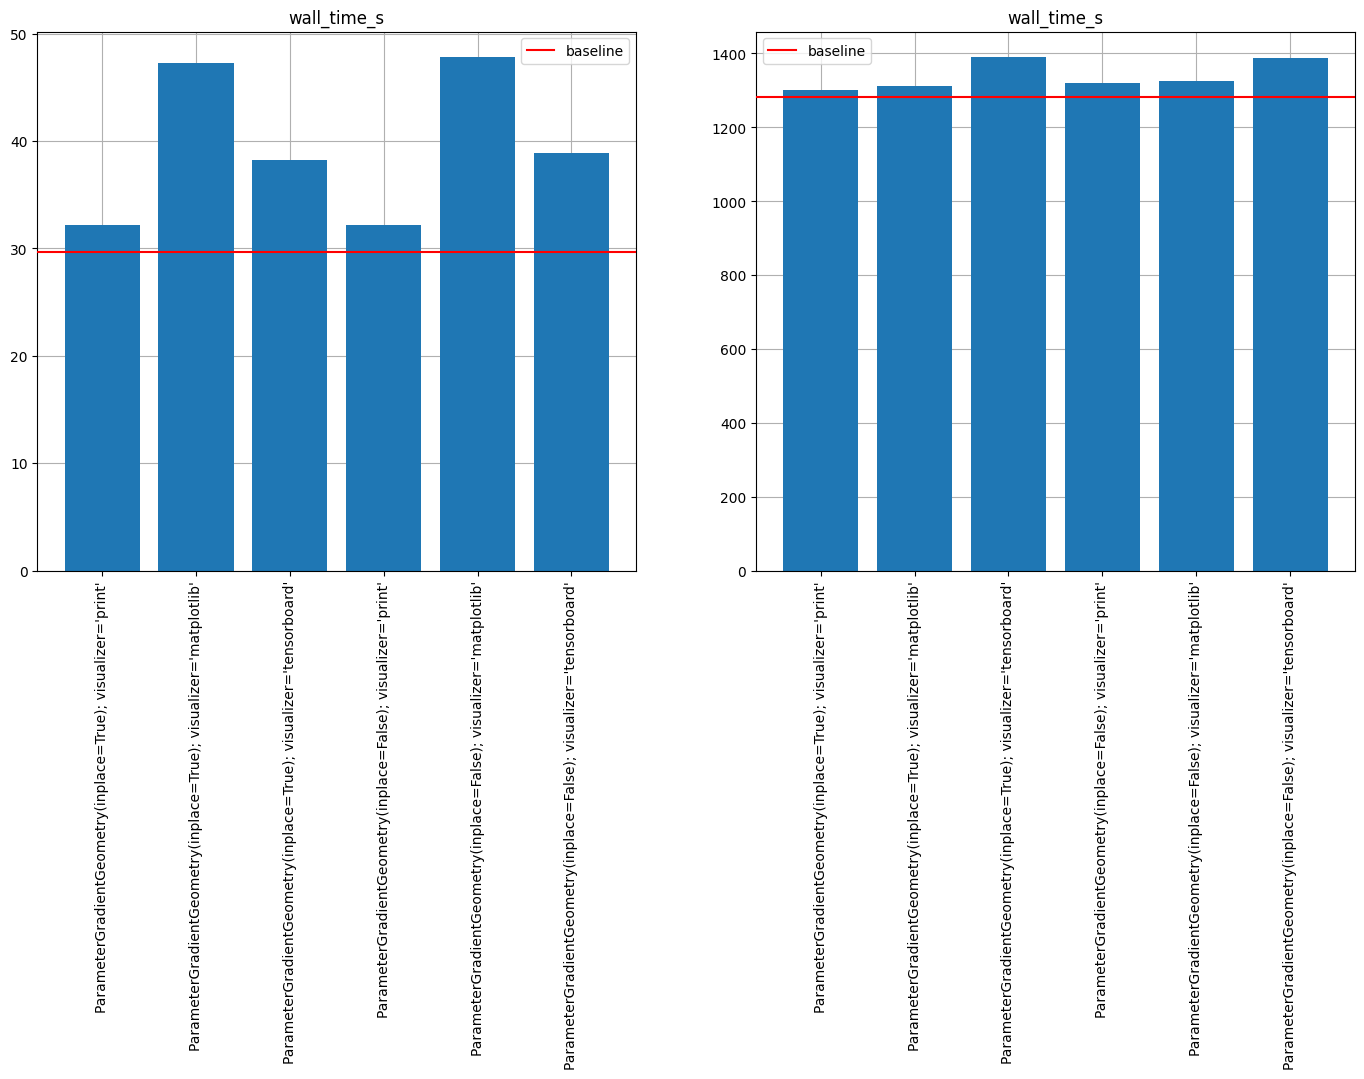

In [69]:

fig, [ax1, ax2] = plt.subplots(figsize=(17, 7), ncols=2)
display_lens_bm('ParameterGradientGeometry', 'wall_time_s', df_gpu, ax1)
fig = display_lens_bm('ParameterGradientGeometry', 'wall_time_s', df_cpu, ax2)

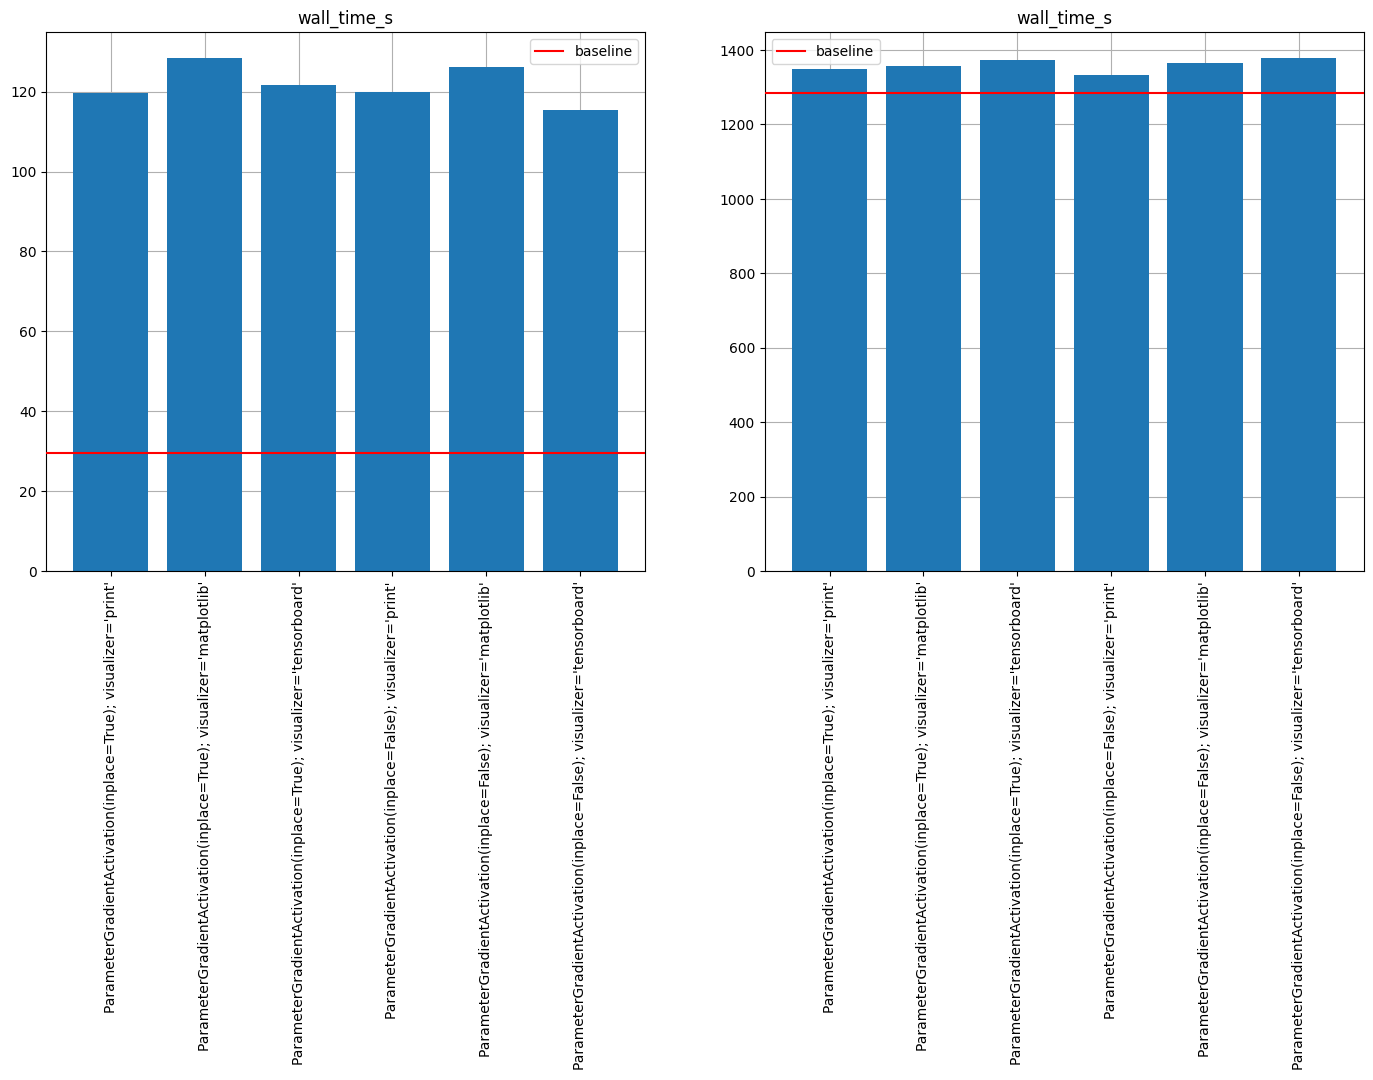

In [70]:

fig, [ax1, ax2] = plt.subplots(figsize=(17, 7), ncols=2)
display_lens_bm('ParameterGradientActivation', 'wall_time_s', df_gpu, ax1)
fig = display_lens_bm('ParameterGradientActivation', 'wall_time_s', df_cpu, ax2)

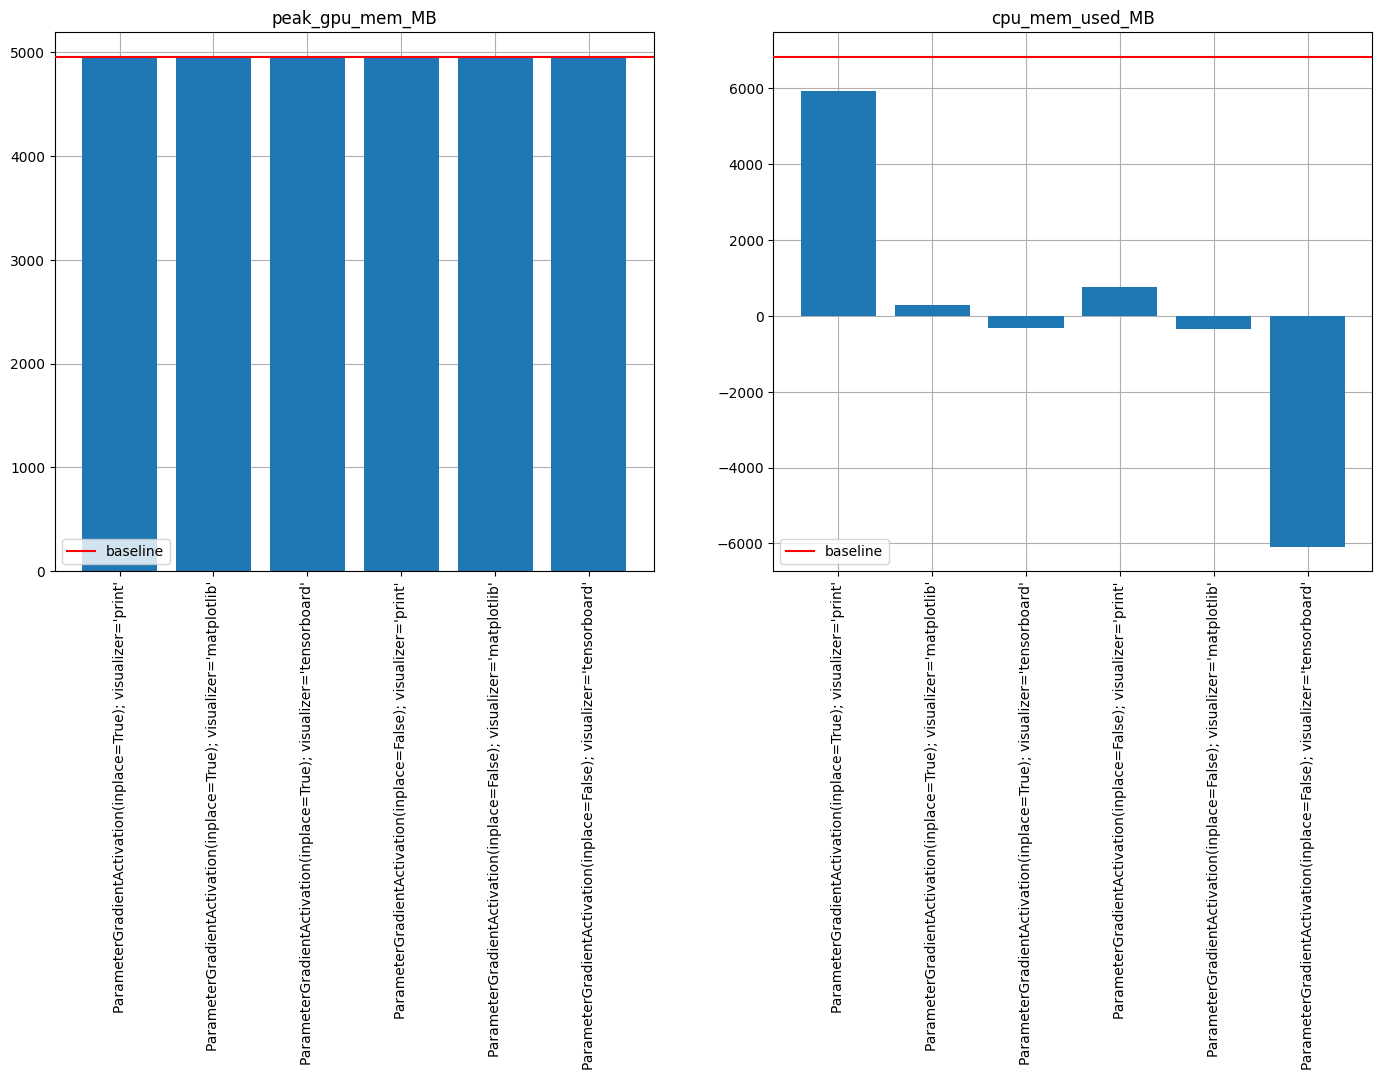

In [75]:

fig, [ax1, ax2] = plt.subplots(figsize=(17, 7), ncols=2)
display_lens_bm('ParameterGradientActivation', 'peak_gpu_mem_MB', df_gpu, ax1)
fig = display_lens_bm('ParameterGradientActivation', 'cpu_mem_used_MB', df_cpu, ax2)

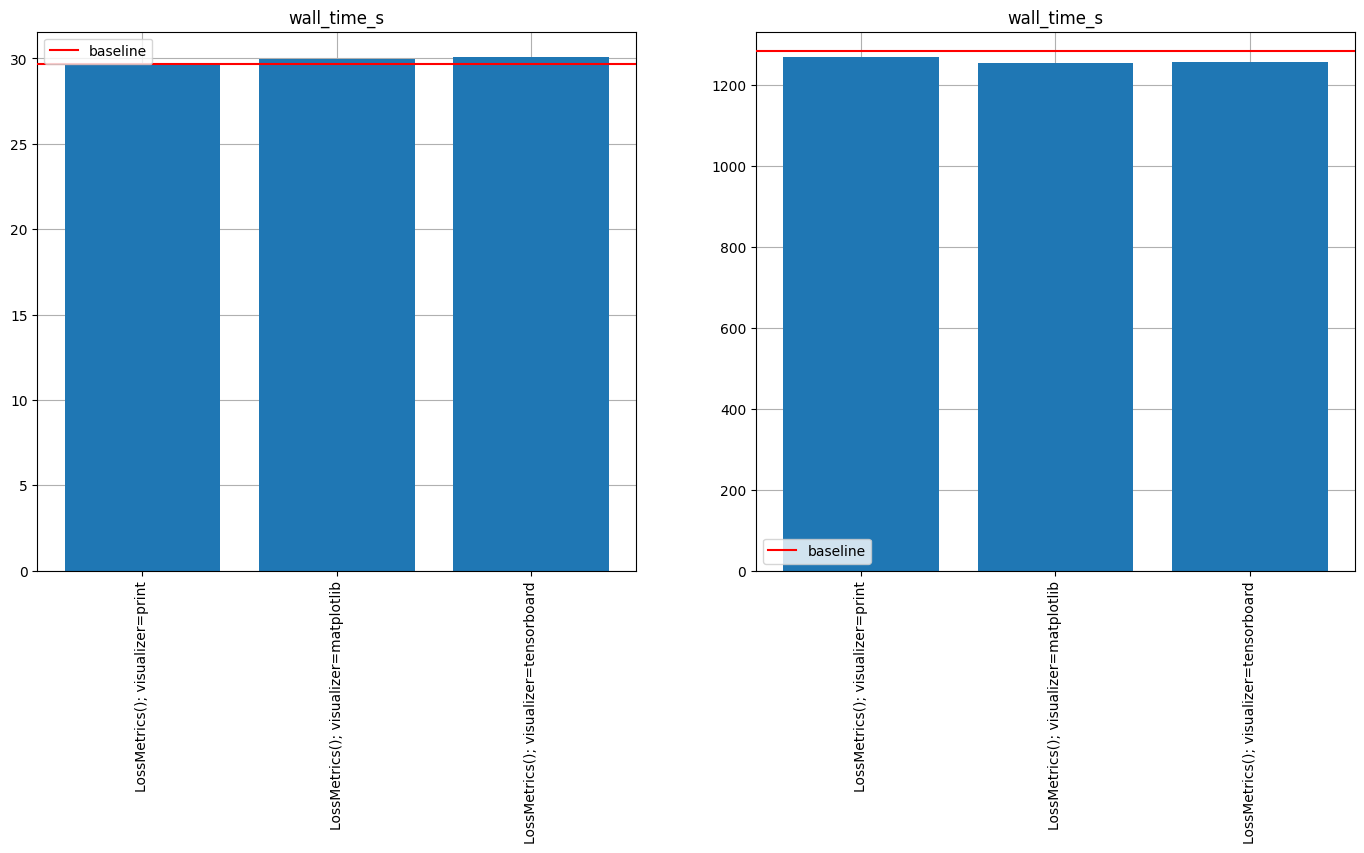

In [73]:

fig, [ax1, ax2] = plt.subplots(figsize=(17, 7), ncols=2)
display_lens_bm('LossMetrics', 'wall_time_s', df_gpu, ax1)
fig = display_lens_bm('LossMetrics', 'wall_time_s', df_cpu, ax2)